# Generate synthetic data for parameter fitting

Runs the Michaelis-Menten model `mm.bngl` with its default parameters, adds 2% noise, and writes the result to `mm.csv`, which `fit_data.ipynb` reads. **Running this notebook overwrites `mm.csv`.**

Simulations use [bngsim](https://bngsim.readthedocs.io), which loads BioNetGen models directly and runs ODE and stochastic (SSA) simulations in-process. `bngsim.Model.from_bngl` generates the reaction network with BioNetGen and loads it; the `simulate` actions at the end of the `.bngl` file are not run.

Two things to remember:
- Parameters are changed on the **model** (`model.set_param`), and simulations are run by a **simulator** (`sim.run`).
- A run starts from the model's *current* state. Call `model.reset()` before each run to start from the initial conditions (this also applies new initial-condition parameters such as `L0`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bngsim

# Load model from BNGL
model_name = 'mm'
model = bngsim.Model.from_bngl('../models/' + model_name + '.bngl')
sim = bngsim.Simulator(model, method="ode")

## Generate synthetic data by running the model with default parameter values

Written to file mm.csv


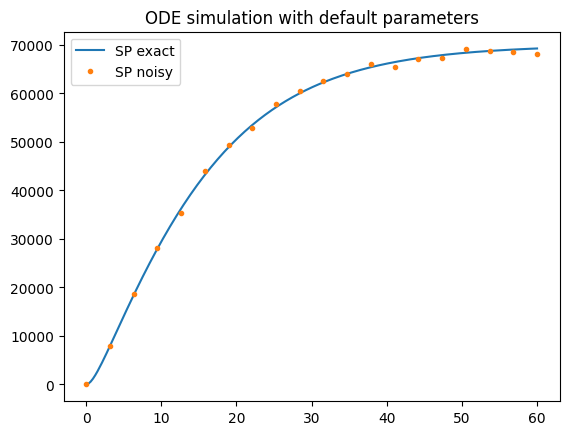

In [2]:
o = model.observable_names[-1]        # fit values of the last observable
times = np.linspace(0, 60, 20)

model.reset()
res = sim.run(sample_times=times)
mod_df = pd.DataFrame({'Time': res.time, o: res.observables[o]})

# Add 2% noise to the observable, except at t=0
rng = np.random.default_rng(seed=1)
noise = rng.normal(loc=0, scale=0.02 * mod_df[o].values[1:])
mod_df.loc[1:, o] += noise
mod_df.to_csv(model_name + '.csv', index=False)
print(f"Written to file {model_name + '.csv'}")

# Run model on a finer time grid
model.reset()
res = sim.run(t_span=(times[0], times[-1]), n_points=200)

plt.plot(res.time, res.observables[o], label=o + ' exact')
plt.plot(mod_df['Time'], mod_df[o], '.', label=o + ' noisy')
plt.title("ODE simulation with default parameters")
_ = plt.legend()